# Step 1 – Access and Extract the Books Dataset



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

zip_file_path = '/content/drive/MyDrive/books.zip'

# Unzip the file
import zipfile
import os

# Create a directory to extract to, if it doesn't exist
extract_dir = 'books_data'
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")

# List the contents of the extracted directory to verify
print(f"Contents of '{extract_dir}':")
for item in os.listdir(extract_dir):
    print(f"- {item}")

'/content/drive/MyDrive/books.zip' unzipped to 'books_data'
Contents of 'books_data':
- books


In [ ]:
import os

books_folder_path = os.path.join(extract_dir, 'books')

if os.path.exists(books_folder_path) and os.path.isdir(books_folder_path):
    print(f"Contents of '{books_folder_path}':")
    for item in os.listdir(books_folder_path):
        print(f"- {item}")
else:
    print(f"The folder '{books_folder_path}' does not exist or is not a directory.")

Contents of 'books_data/books':
- negative.review
- positive.review


In [ ]:
import os

positive_review_path = os.path.join(books_folder_path, 'positive.review')
negative_review_path = os.path.join(books_folder_path, 'negative.review')

def read_and_display_file_sample(file_path, num_lines=5):
    print(f"\n--- Contents of {file_path} (first {num_lines} lines) ---")
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i < num_lines:
                    print(line.strip())
                else:
                    break
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred while reading {file_path}: {e}")

read_and_display_file_sample(positive_review_path)
read_and_display_file_sample(negative_review_path)


--- Contents of books_data/books/positive.review (first 5 lines) ---
<review>
<unique_id>
0785758968:one_of_the_best_crichton_novels:joseph_m
</unique_id>
<asin>

--- Contents of books_data/books/negative.review (first 5 lines) ---
<review>
<unique_id>
0312355645:horrible_book,_horrible.:mark_gospri
</unique_id>
<asin>


In [ ]:
import os

print(os.listdir())



['.config', 'drive', 'books_data', 'sample_data']


In [ ]:
# Search for directories containing the book data
for root, dirs, files in os.walk("."):
    if "books" in root.lower():
        print(root)

./drive/MyDrive/Colab Notebooks
./drive/.Encrypted/MyDrive/Colab Notebooks
./books_data
./books_data/books


# Step 2 – Load Positive and Negative Book Reviews
This step imports the required libraries, defines a function to extract the review text, locates the Books dataset, and loads the positive and negative reviews into memory.


In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_reviews(file_path):
    """
    Extract review text from the Amazon review dataset.
    """

    with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
        content = file.read()

    reviews = re.findall(
        r"<review_text>(.*?)</review_text>",
        content,
        flags=re.DOTALL
    )

    return [review.strip() for review in reviews]

In [ ]:
books_folder = None

for root, dirs, files in os.walk("."):
    if (
        "positive.review" in files
        and "negative.review" in files
        and "books" in root.lower()
    ):
        books_folder = root
        break

print("Books folder:", books_folder)

positive_path = os.path.join(books_folder, "positive.review")
negative_path = os.path.join(books_folder, "negative.review")

positive_reviews = load_reviews(positive_path)
negative_reviews = load_reviews(negative_path)

print("Positive reviews:", len(positive_reviews))
print("Negative reviews:", len(negative_reviews))

Books folder: ./books_data/books
Positive reviews: 1000
Negative reviews: 1000


# Step 3 – Create and Explore the Dataset
The positive and negative reviews are converted into Pandas DataFrames, combined into one dataset, shuffled, and explored for size, class balance, missing values, duplicates, and sample reviews.




In [ ]:
positive_df = pd.DataFrame({
    "review": positive_reviews,
    "sentiment": 1
})

negative_df = pd.DataFrame({
    "review": negative_reviews,
    "sentiment": 0
})


In [ ]:
df = pd.concat(
    [positive_df, negative_df],
    ignore_index=True
)

print("Total number of reviews:", len(df))
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)
df.head(10)

Total number of reviews: 2000


,review,sentiment
0,Can anyone tell me if the book words on the vi...,0
1,I have read all of Van Gulik's murder mysterie...,1
2,There are two things which tickle me about thi...,0
3,John Little and Peter Sisco wrote static contr...,1
4,it is juust a copy of the frist book. if you r...,0
5,My problem was that these books were missing c...,0
6,As an adult I picked this up for my teen daugh...,1
7,Have you ever read a book that just seemed to ...,0
8,Deadly feasts: tracking the secrets of a terri...,1
9,All over the place.\nConfusing. Poorly organiz...,0


Check the dataset size

In [ ]:
print("Dataset shape:", df.shape)


Dataset shape: (2000, 2)


Check positive vs negative reviews

In [ ]:
print(df["sentiment"].value_counts())

sentiment
0    1000
1    1000
Name: count, dtype: int64


Check Missing Values

In [ ]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


Check duplicate reviews

In [ ]:
print("Duplicate reviews:", df.duplicated(subset=["review"]).sum())

Duplicate reviews: 44


Look at some positive reviews

In [ ]:
print("POSITIVE REVIEWS\n")

for review in df[df["sentiment"] == 1]["review"].head(3):
    print(review)
    print("-" * 80)

POSITIVE REVIEWS

I have read all of Van Gulik's murder mysteries and this is has to be my favorite. The characters are intriguing and some sinister. The end is satisfying and bittersweet, challenging integrity vs justice. I would,  however, recommend you read the others first (chronological is good,  Chinese Gold Murders is first) to get to know the main characters although  this book can stand on on its own
--------------------------------------------------------------------------------
John Little and Peter Sisco wrote static contraction... but John takes it a step further and eliminates the need for doing reps with scientific explanations to back up his revolutionary concept of weight training/ muscle building.. My girlfriend and I started doing this method in may of 2005 and I can honestly say i've never found such a fast, quick and easy way to build muscle. This is also a great method for those not wanting to spend hours in a gym... after a while, you only need to workout once a 

Look at some negative reviews

# Step 4 – Clean the Review Text
The review text is cleaned before machine learning. The cleaning function converts text to lowercase, removes HTML tags and URLs, removes unwanted characters, and normalises extra spaces.


In [ ]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep letters and apostrophes
    text = re.sub(r"[^a-zA-Z']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()



In [ ]:
example = "This BOOK was AMAZING!!! I loved it 100% <br>"

print("Before:")
print(example)

print("\nAfter:")
print(clean_text(example))

Before:
This BOOK was AMAZING!!! I loved it 100% <br>

After:
this book was amazing i loved it


Apply it to the complete dataset

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)

Check the result

In [ ]:
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,Can anyone tell me if the book words on the vi...,can anyone tell me if the book words on the vi...,0
1,I have read all of Van Gulik's murder mysterie...,i have read all of van gulik's murder mysterie...,1
2,There are two things which tickle me about thi...,there are two things which tickle me about thi...,0
3,John Little and Peter Sisco wrote static contr...,john little and peter sisco wrote static contr...,1
4,it is juust a copy of the frist book. if you r...,it is juust a copy of the frist book if you re...,0


calculating number of words in each review

# Step 5 – Remove Very Short or Unsuitable Reviews
The number of words in each cleaned review is calculated. Reviews that are too short to provide useful sentiment information are removed, along with empty and duplicate cleaned reviews.


In [ ]:
df["word_count"] = df["clean_review"].apply(
    lambda x: len(x.split())
)

Look at the statistics


In [ ]:
df["word_count"].describe()

,word_count
count,2000.000000
mean,173.101000
std,193.219144
min,1.000000
25%,64.000000
50%,111.000000
75%,211.000000
max,3330.000000


remove reviews shorter than 5 words

In [ ]:
MIN_WORDS = 5

before_removal = len(df)

df = df[df["word_count"] >= MIN_WORDS].copy()

after_removal = len(df)

print("Reviews before removal:", before_removal)
print("Reviews after removal:", after_removal)
print("Reviews removed:", before_removal - after_removal)

Reviews before removal: 2000
Reviews after removal: 1998
Reviews removed: 2


Remove empty reviews

In [ ]:
df = df[df["clean_review"].str.strip() != ""]

Remove duplicate reviews

In [ ]:
df = df.drop_duplicates(
    subset=["clean_review"]
).reset_index(drop=True)

Check the final size:

In [ ]:
print("Clean dataset size:", len(df))

Clean dataset size: 1954


Check the class distribution

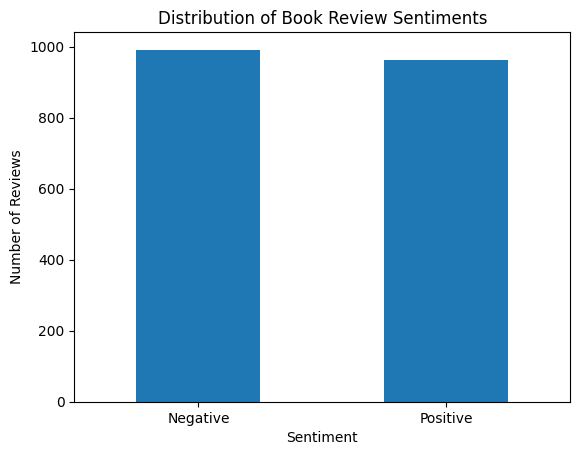

In [ ]:
df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Negative", "Positive"],
    rotation=0
)

plt.title("Distribution of Book Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# Step 6 – Encode the Sentiment Labels
The sentiment classes are represented numerically so that they can be used by the neural network:

- `0` = Negative
- `1` = Positive


In [ ]:
label_mapping = {
    0: "Negative",
    1: "Positive"
}

df["sentiment_text"] = df["sentiment"].map(label_mapping)
df[
    ["clean_review", "sentiment", "sentiment_text"]
].head(10)

,clean_review,sentiment,sentiment_text
0,can anyone tell me if the book words on the vi...,0,Negative
1,i have read all of van gulik's murder mysterie...,1,Positive
2,there are two things which tickle me about thi...,0,Negative
3,john little and peter sisco wrote static contr...,1,Positive
4,it is juust a copy of the frist book if you re...,0,Negative
5,my problem was that these books were missing c...,0,Negative
6,as an adult i picked this up for my teen daugh...,1,Positive
7,have you ever read a book that just seemed to ...,0,Negative
8,deadly feasts tracking the secrets of a terrif...,1,Positive
9,all over the place confusing poorly organized ...,0,Negative


In [ ]:
y = df["sentiment"].values
print(y[:20])

[0 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 0]


# Step 7 – Tokenise and Encode the Review Text
The cleaned review text is converted into integer sequences using a Keras Tokenizer. The vocabulary size is limited to the 10,000 most common words, with an out-of-vocabulary token for unseen words.


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
VOCAB_SIZE = 10000
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)


Train the tokenizer on the cleaned reviews

In [ ]:
tokenizer.fit_on_texts(
    df["clean_review"]
)

convert the reviews into sequences of numbers:

In [ ]:
sequences = tokenizer.texts_to_sequences(
    df["clean_review"]
)

print("Original review:")
print(df["clean_review"].iloc[0])

print("\nEncoded review:")
print(sequences[0])

Original review:
can anyone tell me if the book words on the vine has an answer key with it thanks sgra

Encoded review:
[51, 173, 258, 54, 35, 2, 12, 271, 18, 2, 1, 39, 33, 912, 913, 16, 13, 1480, 1]


Test the tokenizer

In [ ]:
test_reviews = [
    "this book was amazing",
    "this book was terrible"
]

test_sequences = tokenizer.texts_to_sequences(
    test_reviews
)

print(test_sequences)

[[10, 12, 19, 665], [10, 12, 19, 1059]]


Saveing  cleaned dataset

In [ ]:
df.to_csv(
    "cleaned_book_reviews.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


Reviews shorter than 250 tokens will be padded with zeros, while reviews longer than 250 tokens will be truncated

# Step 8 – Pad and Truncate the Encoded Reviews
Neural networks require inputs of a consistent length. Each review sequence is therefore padded or truncated to a maximum length of **250 tokens**.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 250

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Shape of padded data:", padded_sequences.shape)

Shape of padded data: (1954, 250)


Example:

In [ ]:
print("Original token sequence:")
print(sequences[0][:50])

print("\nPadded sequence:")
print(padded_sequences[0][:50])

print("\nTotal padded length:")
print(len(padded_sequences[0]))

Original token sequence:
[51, 173, 258, 54, 35, 2, 12, 271, 18, 2, 1, 39, 33, 912, 913, 16, 13, 1480, 1]

Padded sequence:
[  51  173  258   54   35    2   12  271   18    2    1   39   33  912
  913   16   13 1480    1    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]

Total padded length:
250


Prepare the labels

In [ ]:
import numpy as np

X = padded_sequences
y = df["sentiment"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1954, 250)
y shape: (1954,)


Here we will use,

*   70% Training
*   15% Validation
*   15% Testing






# Step 9 – Split the Dataset into Training, Validation, and Test Sets
The encoded dataset is divided into:

- **70% Training** – used to train the model
- **15% Validation** – used to monitor performance and compare model architectures
- **15% Testing** – kept untouched until the final evaluation

Stratified splitting is used to maintain a similar positive/negative class balance in each subset.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

Check Training, validation and Test sets

In [ ]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 1367
Validation samples: 293
Testing samples: 294


In [ ]:
total = len(X)

print(f"Training:   {len(X_train)/total*100:.2f}%")
print(f"Validation: {len(X_val)/total*100:.2f}%")
print(f"Testing:    {len(X_test)/total*100:.2f}%")

Training:   69.96%
Validation: 14.99%
Testing:    15.05%




*   Set random seeds




# Step 10 – Build the Initial Neural Network
Random seeds are set for reproducibility. The initial model uses an Embedding layer, a Bidirectional LSTM, Dropout regularisation, a Dense layer, and a Sigmoid output for binary sentiment classification.


In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)



*   Define the model



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

VOCAB_SIZE = 10000
EMBEDDING_DIM = 128

model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])



*   Compile the Model




In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



*   model architecture



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

# Step 11 – Train and Analyse the Initial Model
The initial neural network is trained using the training set while validation performance is monitored. Early stopping and model checkpointing are used to reduce unnecessary training and preserve the best-performing version.

Training and validation accuracy/loss are then plotted to identify whether the model is learning effectively or overfitting.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_book_sentiment_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,

    batch_size=32,

    callbacks=[
        early_stopping,
        model_checkpoint
    ],

    verbose=1
)

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 404ms/step - accuracy: 0.5289 - loss: 0.6912 - val_accuracy: 0.5563 - val_loss: 0.6873
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 375ms/step - accuracy: 0.6796 - loss: 0.6138 - val_accuracy: 0.6280 - val_loss: 0.6273
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 379ms/step - accuracy: 0.8910 - loss: 0.2857 - val_accuracy: 0.6485 - val_loss: 0.6396
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 372ms/step - accuracy: 0.9744 - loss: 0.0795 - val_accuracy: 0.6519 - val_loss: 0.9918
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 371ms/step - accuracy: 0.9839 - loss: 0.0597 - val_accuracy: 0.6758 - val_loss: 0.9138


. display final results

In [ ]:
print("Training completed.")

print(
    "Final training accuracy:",
    history.history["accuracy"][-1]
)

print(
    "Final validation accuracy:",
    history.history["val_accuracy"][-1]
)

Training completed.
Final training accuracy: 0.9839063882827759
Final validation accuracy: 0.6757678985595703


Training Accuracy Plot

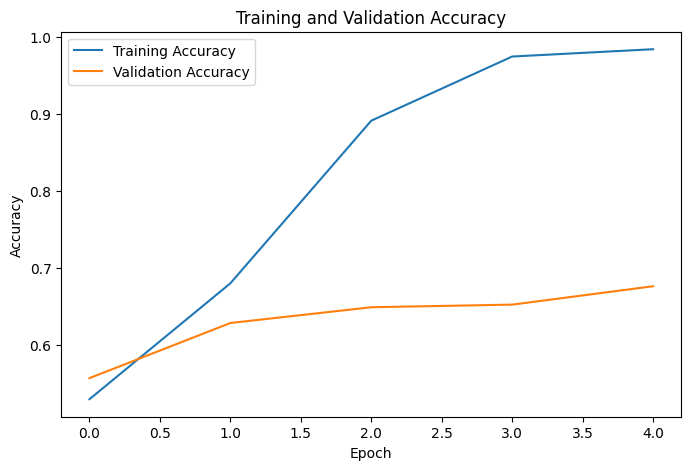

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

Training Loss Plot

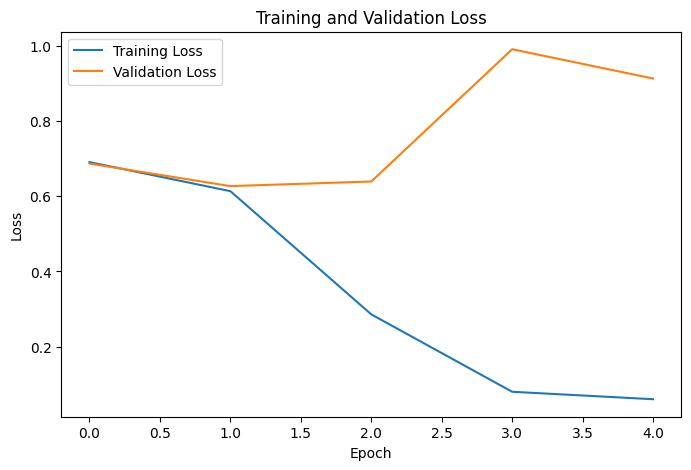

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

1.Replacing the current model with a smaller LSTM model

## Step 11A – Improvement 1: Smaller LSTM Model
The initial model showed overfitting, so a smaller LSTM architecture with stronger dropout and L2 regularisation is tested to improve generalisation.


In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(MAX_LEN,)),

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        mask_zero=True
    ),

    tf.keras.layers.LSTM(
        32,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

compile the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,505 (2.49 MB)

 Trainable params: 653,505 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

2. Use stronger EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=0.00001,
    verbose=1
)

Retain

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 16s 271ms/step - accuracy: 0.4843 - loss: 0.7238 - val_accuracy: 0.5290 - val_loss: 0.7206 - learning_rate: 5.0000e-04
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - accuracy: 0.5743 - loss: 0.7165 - val_accuracy: 0.5392 - val_loss: 0.7147 - learning_rate: 5.0000e-04
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.6620 - loss: 0.7015 - val_accuracy: 0.5461 - val_loss: 0.7055 - learning_rate: 5.0000e-04
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.7652 - loss: 0.6407 - val_accuracy: 0.6212 - val_loss: 0.6698 - learning_rate: 5.0000e-04
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 265ms/step - accuracy: 0.8296 - loss: 0.5318 - val_accuracy: 0.6792 - val_loss: 0.6117 - learning_rate: 5.0000e-04
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8693 - loss: 0.4357
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 271ms/step - accuracy:

Accuracy Graph

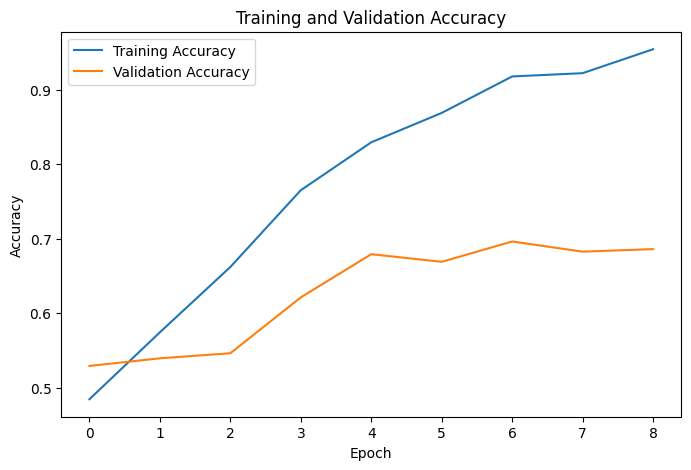

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

3. Use simpler model based on Global Average Pooling instead of LSTM.

## Step 11B – Improvement 2: Global Average Pooling Model
A simpler architecture using Global Average Pooling is tested to reduce model complexity and compare its validation performance with the LSTM models.


In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        mask_zero=False
    ),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,113 (2.45 MB)

 Trainable params: 642,113 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

Train model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4865 - loss: 0.7300 - val_accuracy: 0.5085 - val_loss: 0.7209
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5245 - loss: 0.7153 - val_accuracy: 0.5085 - val_loss: 0.7109
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5406 - loss: 0.7047 - val_accuracy: 0.5119 - val_loss: 0.7039
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5486 - loss: 0.6982 - val_accuracy: 0.5290 - val_loss: 0.6982
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5801 - loss: 0.6890 - val_accuracy: 0.5324 - val_loss: 0.6955
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6130 - loss: 0.6769 - val_accuracy: 0.5836 - val_loss: 0.6886
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6196 - loss: 0.6698 - val_accuracy: 0.5734 - val_loss: 0.6874
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6847 - loss: 0.6357 - val_accuracy: 0.6553 - v

Accuracy plot

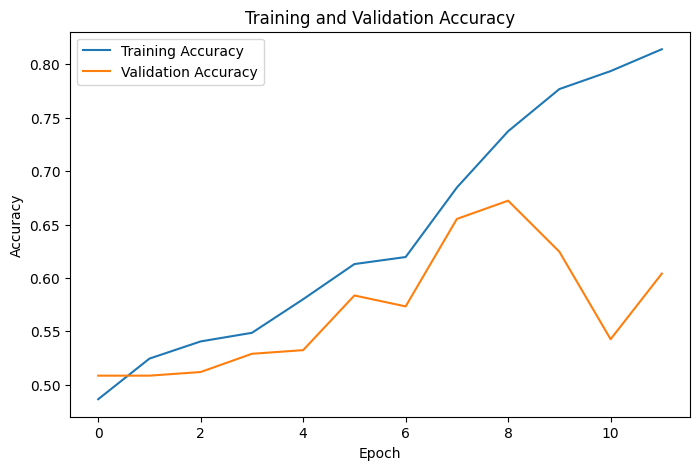

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

Use 1D CNN

## Step 11C – Improvement 3: 1D Convolutional Neural Network (CNN)
A 1D CNN is tested because convolutional layers can identify useful local word patterns in review sequences while remaining computationally efficient.

This model ultimately provides the strongest validation performance and is selected as the final model.


In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(MAX_LEN,)),

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    tf.keras.layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    ),

    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

Compile the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 246, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,370,369 (5.23 MB)

 Trainable params: 1,370,369 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_cnn_book_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

Train the Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=1
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5051 - loss: 0.7830
Epoch 1: val_loss improved from None to 0.76851, saving model to best_cnn_book_model.keras

Epoch 1: finished saving model to best_cnn_book_model.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.5135 - loss: 0.7765 - val_accuracy: 0.5085 - val_loss: 0.7685
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5614 - loss: 0.7578
Epoch 2: val_loss improved from 0.76851 to 0.75981, saving model to best_cnn_book_model.keras

Epoch 2: finished saving model to best_cnn_book_model.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5508 - loss: 0.7577 - val_accuracy: 0.5085 - val_loss: 0.7598
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6199 - loss: 0.7431
Epoch 3: val_loss improved from 0.75981 to 0.74890, saving model to best_cnn_book_model.keras

Epoch 3: finished saving model to best_cnn_book_model.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accura

Accuracy Plot

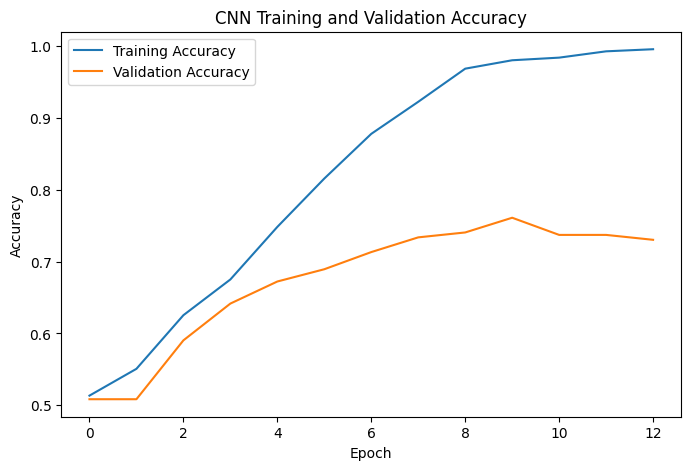

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
model.save("best_cnn_book_model.keras")

**Model Comparison**

| Model                  | Approx. best validation accuracy | Comment            |
| ---------------------- | -------------------------------: | ------------------ |
| Bidirectional LSTM     |                             ~68% | Severe overfitting |
| Smaller LSTM           |                          ~69–70% | Slight improvement |
| Global Average Pooling |                             ~67% | Lower performance  |
| **1D CNN**             |                         **~76%** | **Best so far**    |


# Step 12 – Load and Evaluate the Best CNN Model
The saved CNN model is loaded and evaluated using the previously untouched test set.



In [ ]:
import tensorflow as tf

best_model = tf.keras.models.load_model(
    "best_cnn_book_model.keras"
)

print("Best CNN model loaded.")

Best CNN model loaded.


Evaluate the untouched test data

In [ ]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7551 - loss: 0.5489
Test Loss: 0.5489
Test Accuracy: 0.7551
Test Accuracy Percentage: 75.51%


Generate predictions

In [ ]:
y_prob = best_model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int).flatten()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[110  35]
 [ 37 112]]


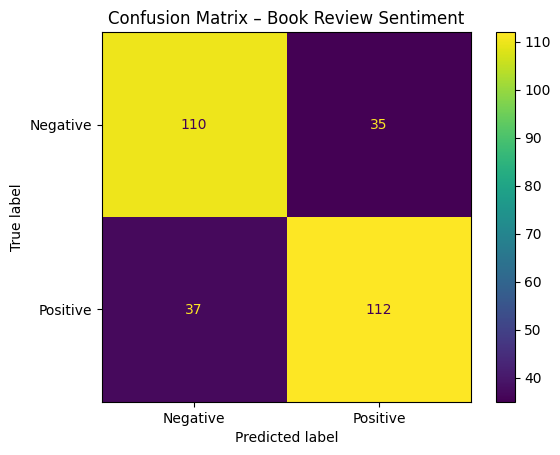

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix – Book Review Sentiment"
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.75      0.76      0.75       145
    Positive       0.76      0.75      0.76       149

    accuracy                           0.76       294
   macro avg       0.76      0.76      0.76       294
weighted avg       0.76      0.76      0.76       294



# Step 13 – Save the Tokenizer for Deployment



In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

from google.colab import files

files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 14 – Test the Final Model on New Book Reviews



In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def predict_sentiment(review):

    # Use our existing cleaning function
    cleaned_review = clean_text(review)

    # Convert words into tokens
    sequence = tokenizer.texts_to_sequences(
        [cleaned_review]
    )

    # Pad to 250 tokens
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # Predict
    probability = best_model.predict(
        padded,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    print("Review:")
    print(review)

    print("\nPrediction:", sentiment)

    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

Testing Positive Review

In [ ]:
predict_sentiment(
    "This book was fantastic. The story was engaging and the characters were beautifully written."
)

Review:
This book was fantastic. The story was engaging and the characters were beautifully written.

Prediction: Positive
Confidence: 72.97%


Testing Negative Review

In [ ]:
predict_sentiment(
    "This book was extremely boring and poorly written. I regret buying it."
)

Review:
This book was extremely boring and poorly written. I regret buying it.

Prediction: Negative
Confidence: 99.09%


In [ ]:
predict_sentiment(
    "The story was interesting but the ending was very disappointing."
)

Review:
The story was interesting but the ending was very disappointing.

Prediction: Negative
Confidence: 93.85%


Download Best Model

# Step 15 – Download the Final Trained Model
The selected CNN model is downloaded for use in the Streamlit web application and GitHub project.


In [ ]:
files.download(
    "best_cnn_book_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>